# Проект: классификация

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [2]:
df = pd.read_csv('bank_fin.csv', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


**Данные о клиентах банка**:

* `age` (возраст);
* `job` (сфера занятости);
* `marital` (семейное положение);
* `education` (уровень образования);
* `default` (имеется ли просроченный кредит);
* `housing` (имеется ли кредит на жильё);
* `loan` (имеется ли кредит на личные нужды);
* `balance` (баланс).

**Данные, связанные с последним контактом в контексте текущей маркетинговой кампании**:

* `contact` (тип контакта с клиентом);
* `month` (месяц, в котором был последний контакт);
* `day` (день, в который был последний контакт);
* `duration` (продолжительность контакта в секундах).

**Прочие признаки**:

* `campaign` (количество контактов с этим клиентом в течение текущей кампании);
* `pdays` (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);
* `previous` (количество контактов до текущей кампании)
* `poutcome` (результат прошлой маркетинговой кампании).

И, разумеется, наша **целевая переменная** `deposit`, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


### Задание 2

In [4]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [5]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance'] = df['balance'].str.replace('$', '', regex=False)  # Удаление символа $
df['balance'] = df['balance'].str.replace(',00', '')  # Удаление запятых
df['balance'] = df['balance'].str.replace(' ', '')  # Удаление пробелов
df['balance'] = df['balance'].astype(float)  # Преобразование в числовой тип
round(df['balance'].mean(), 3)

1529.129

### Задание 4

In [6]:
df['balance'] = df['balance'].fillna(df['balance'].median()) #Заполняем пропуски медианным значением по признаку
round(df['balance'].mean(), 3)

1526.936

### Задание 5

In [7]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
for column in ['job', 'education']:
    mode_value = df[column].mode()[0]
    df.loc[df[column] == 'unknown', column] = mode_value
    
mask = df[(df['job'] == df['job'].mode()[0]) & (df['education'] == df['education'].mode()[0])]
round(mask['balance'].mean(), 3)

1598.883

### Задание 6

In [8]:
# удалите все выбросы для признака balance
print(f'Исходное количество записей: {df.shape[0]}')

x = df['balance']
quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
iqr = quartile_3 - quartile_1
lower_bound = quartile_1 - (iqr * 1.5)
upper_bound = quartile_3 + (iqr * 1.5)

# Вывод значений границ
print(f'Нижняя граница: {round(lower_bound)}')
print(f'Верхняя граница: {round(upper_bound)}')

# Поиск выбросов
outliers = df[(x < lower_bound) | (x > upper_bound)]
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')

# Фильтрация данных
df = df[(x >= lower_bound) & (x <= upper_bound)]
print(f'Результирующее число записей: {df.shape[0]}')

Исходное количество записей: 11162
Нижняя граница: -2241
Верхняя граница: 4063
Число выбросов по методу Тьюки: 1057
Результирующее число записей: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

deposit
no     5424
yes    4681
Name: count, dtype: int64


<Axes: xlabel='deposit', ylabel='count'>

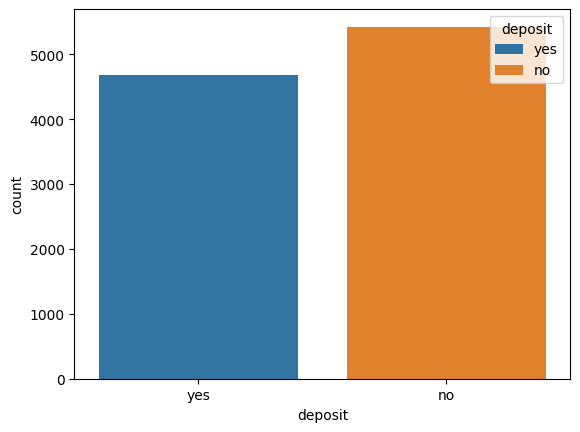

In [9]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
print(df['deposit'].value_counts())
sns.countplot(data=df, x= 'deposit', hue = 'deposit', legend='full')

>Классы практически сбалансированы

### Задания 2 и 3

In [10]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
print(df.describe())

                age       balance           day      duration      campaign  \
count  10105.000000  10105.000000  10105.000000  10105.000000  10105.000000   
mean      40.895497    807.653538     15.590302    368.742603      2.517170   
std       11.734931    994.151966      8.441510    346.651524      2.707159   
min       18.000000  -2049.000000      1.000000      2.000000      1.000000   
25%       32.000000     95.000000      8.000000    137.000000      1.000000   
50%       38.000000    445.000000     15.000000    252.000000      2.000000   
75%       48.000000   1227.000000     22.000000    490.000000      3.000000   
max       95.000000   4063.000000     31.000000   3881.000000     43.000000   

              pdays      previous  
count  10105.000000  10105.000000  
mean      51.319644      0.816230  
std      109.644179      2.243795  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%        2.000000      1.000000  


In [11]:
types = df.dtypes
num_features = list(df.select_dtypes(include=['int64', 'float64']).columns)
num_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [12]:
df['deposit'] = df['deposit'].apply(lambda x:int(1) if x == 'yes' else int(0))

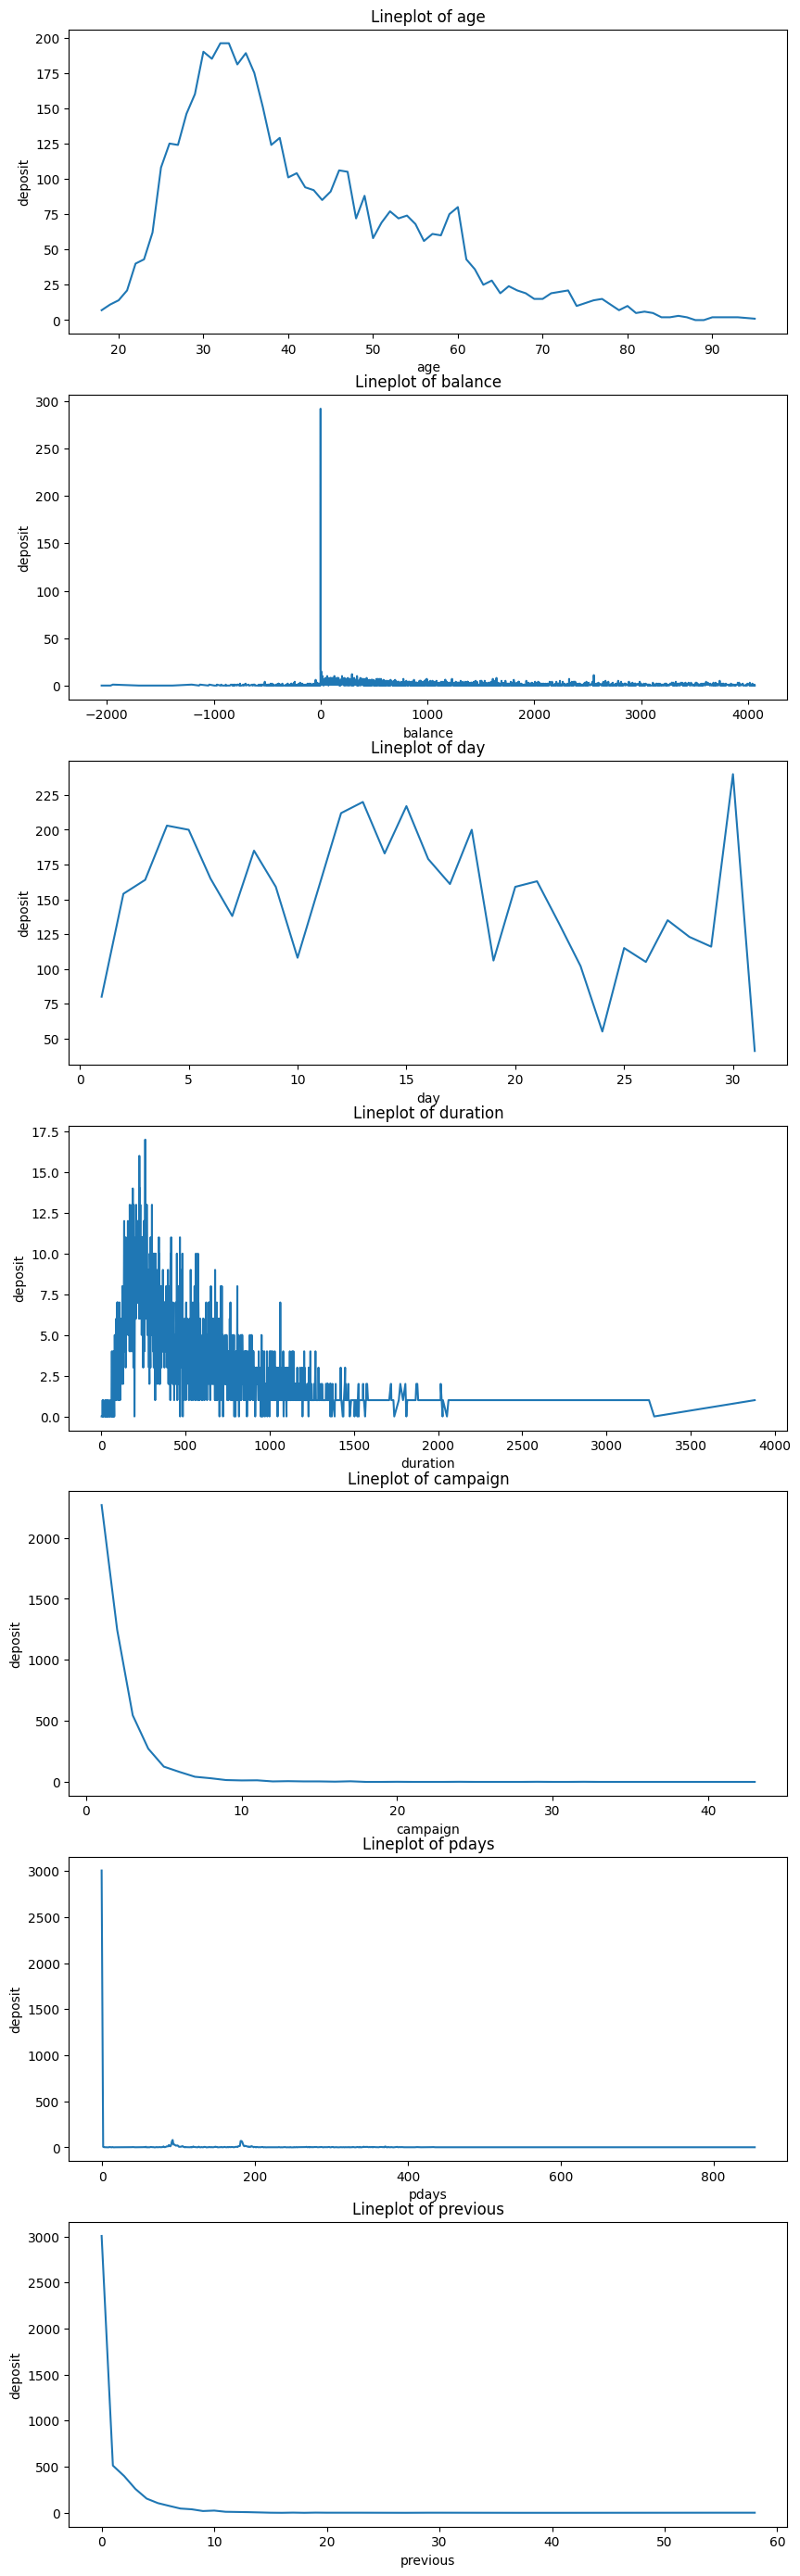

In [13]:
n = len(num_features)
fig, axes = plt.subplots(n, 1, figsize=(10, 5*n))
for idx, feature in enumerate(num_features):
    sns.lineplot(data=pd.DataFrame(df.groupby(feature)['deposit'].sum()).reset_index(), x=feature, y='deposit', ax=axes[idx])
    axes[idx].set_title(f'Lineplot of {feature}')

### Задания 4 и 5

In [14]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome
count,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4
top,management,married,secondary,no,no,no,cellular,may,unknown
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570


In [15]:
types = df.dtypes
cat_features = list(types[(types == 'object')].index)
cat_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

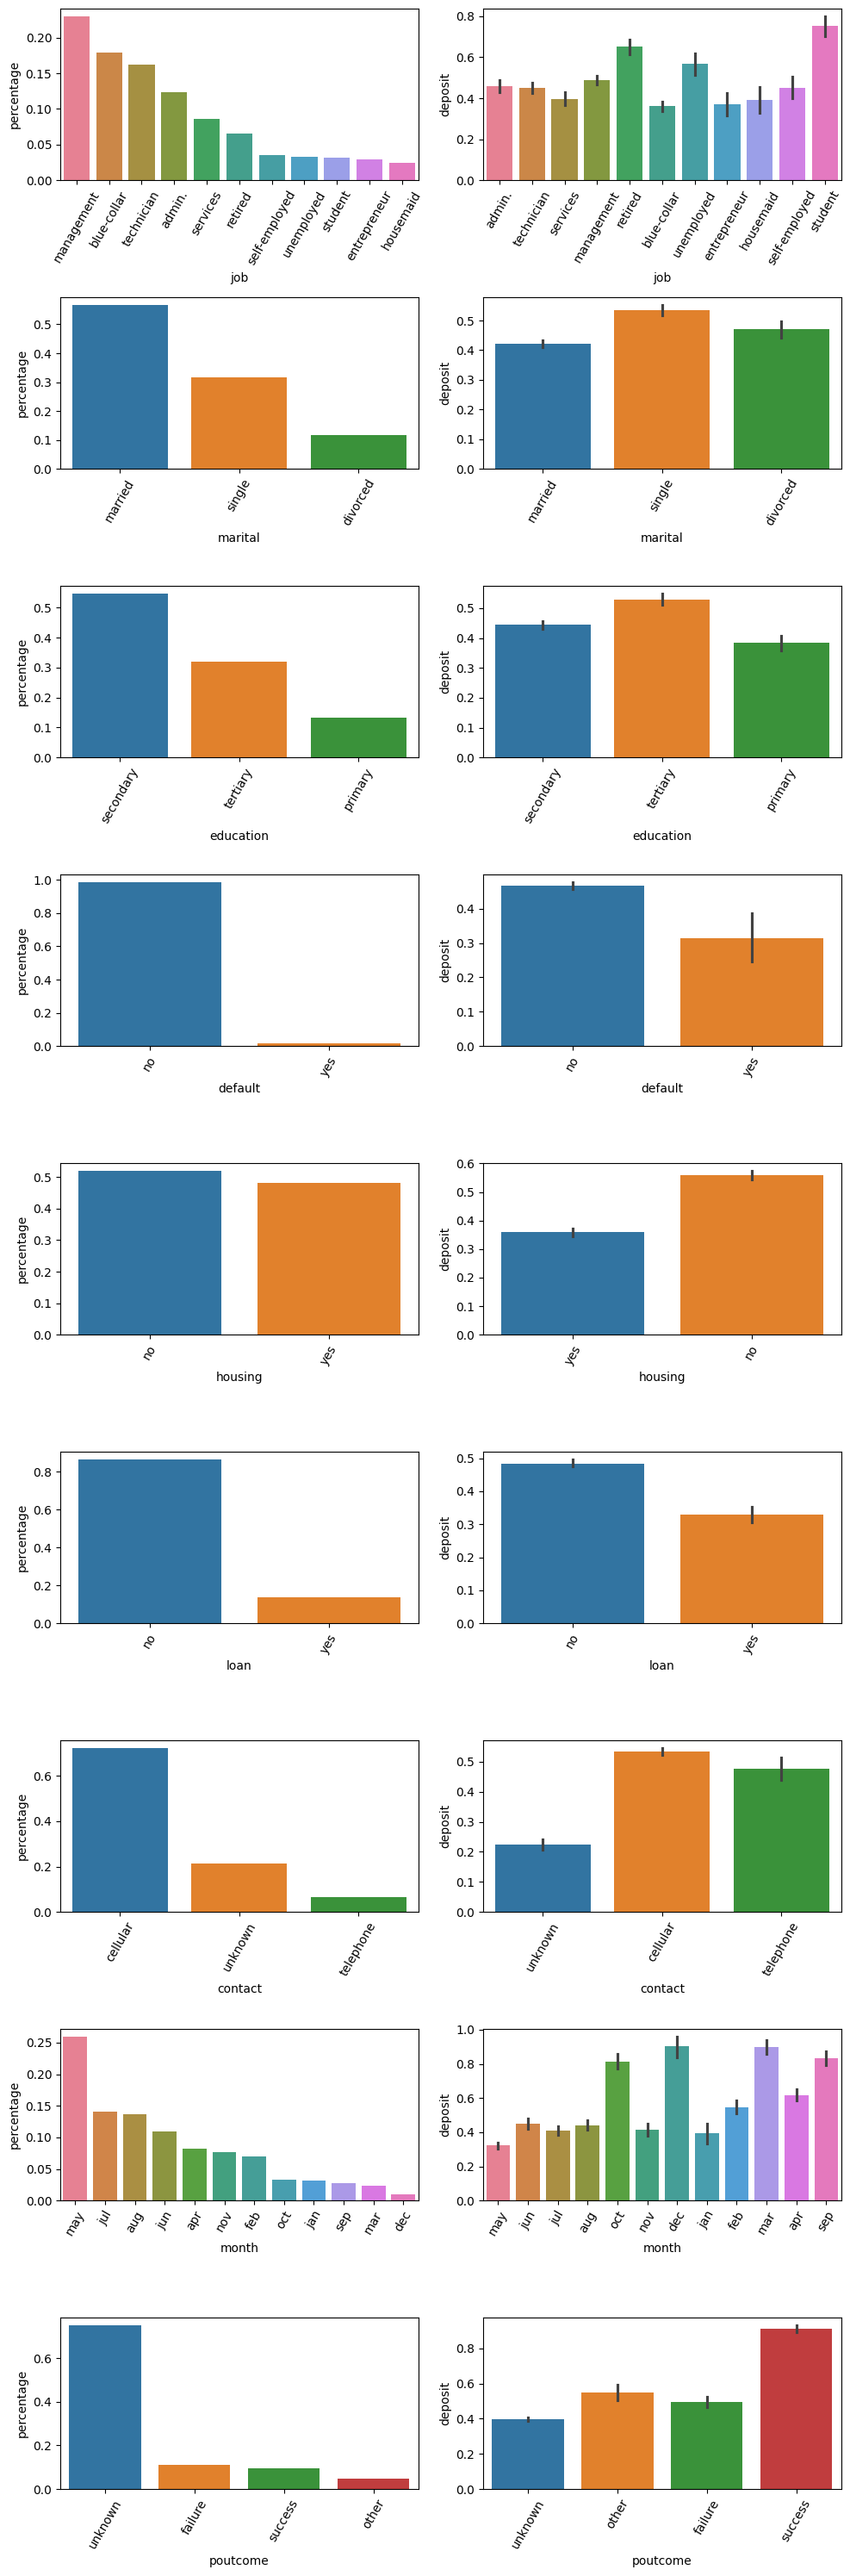

In [16]:
c = len(cat_features) #число категориальных признаков
fig, axes = plt.subplots(c, 2, figsize=(10, 30)) #фигура+n*2 координатных плоскостей
#Создаём цикл для всех признаков из списка категориальных признаков
for i, feature in enumerate(cat_features):
    #Строим количественную столбчатую диаграмму для долевого соотношения каждой из категорий в данных
    count_data = (df[feature].value_counts(normalize=True)
                  .sort_values(ascending=False)
                  .rename('percentage')
                  .reset_index()
                  .rename(columns={'index': feature}))
    count_barplot = sns.barplot(data=count_data, x=feature, y='percentage', hue = feature, ax=axes[i][0])
    count_barplot.xaxis.set_tick_params(rotation=60)
    #Строим столбчатую диаграмму доли людей согласных открыть депозит в зависимости от категории
    mean_barplot = sns.barplot(data=df, x=feature, y='deposit', hue = feature, ax=axes[i][1])
    mean_barplot.xaxis.set_tick_params(rotation=60)
plt.tight_layout() #выравнивание графиков

### Задание 6

In [17]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
df.groupby('poutcome')['deposit'].value_counts()

poutcome  deposit
failure   0           562
          1           547
other     1           265
          0           216
success   1           861
          0            84
unknown   0          4562
          1          3008
Name: count, dtype: int64

### Задание 7

In [18]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
failure_rate = df.groupby('month')['deposit'].apply(lambda x: (x == 0).mean() * 100)

max_failure_month = failure_rate.idxmax()
max_failure_rate = failure_rate.max()

print(f"Месяц с наибольшим процентом неудач: {max_failure_month} ({max_failure_rate:.2f}%)")

Месяц с наибольшим процентом неудач: may (67.86%)


### Задание 8

In [19]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, float('inf')],
    labels=['<30', '30-40', '40-50', '50-60', '60+']
)

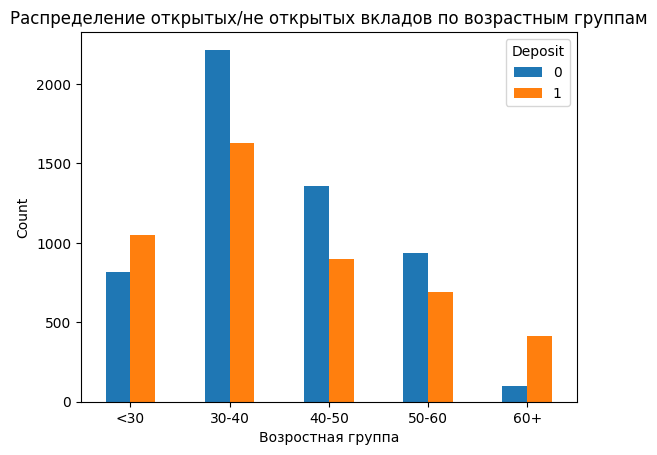

In [20]:
age_group_data = df.groupby(['age_group', 'deposit']).size().unstack().fillna(0)
ax = age_group_data.plot(kind='bar', stacked=False)
plt.xlabel('Возростная группа')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title('Распределение открытых/не открытых вкладов по возрастным группам')
plt.legend(title='Deposit', labels=['0', '1'])
plt.show()

In [21]:
df.groupby('age_group')['deposit'].value_counts()

age_group  deposit
<30        1          1051
           0           819
30-40      0          2215
           1          1627
40-50      0          1360
           1           895
50-60      0           933
           1           692
60+        1           416
           0            97
Name: count, dtype: int64

>Две возрастные группы, которые более склонны открывать депозит - <30 и 60+

### Задания 9 и 10

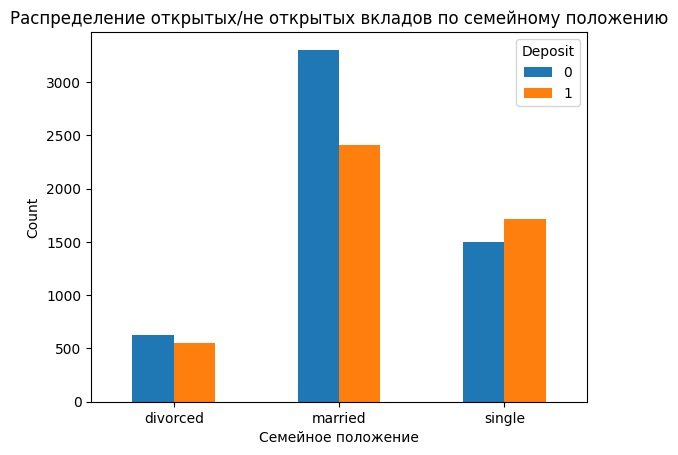

In [22]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
marital_data = df.groupby(['marital', 'deposit']).size().unstack().fillna(0)
ax = marital_data.plot(kind='bar', stacked=False)
plt.xlabel('Семейное положение')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title('Распределение открытых/не открытых вкладов по семейному положению')
plt.legend(title='Deposit', labels=['0', '1'])
plt.show()

>По графику видно что наибольшое количество клиентов банка женаты/замужем (**'married'**), а при семейном положении - холост(**'single'**) чаще открывают депозит, чем не открывают.

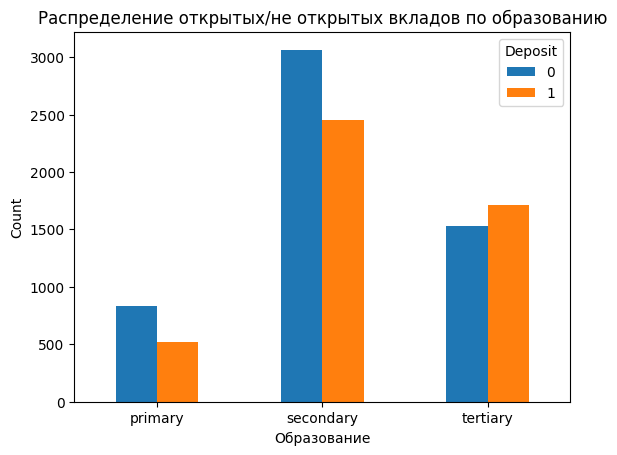

In [23]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
education_data = df.groupby(['education', 'deposit']).size().unstack().fillna(0)
ax = education_data.plot(kind='bar', stacked=False)
plt.xlabel('Образование')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.title('Распределение открытых/не открытых вкладов по образованию')
plt.legend(title='Deposit', labels=['0', '1'])
plt.show()

>По графику видно что наибольшое количество клиентов банка имеет среднее образование (**'secondary'**), а чаще открывают, чем не открывают депозит клиенты с высшем образованием (**'tertiary'**)

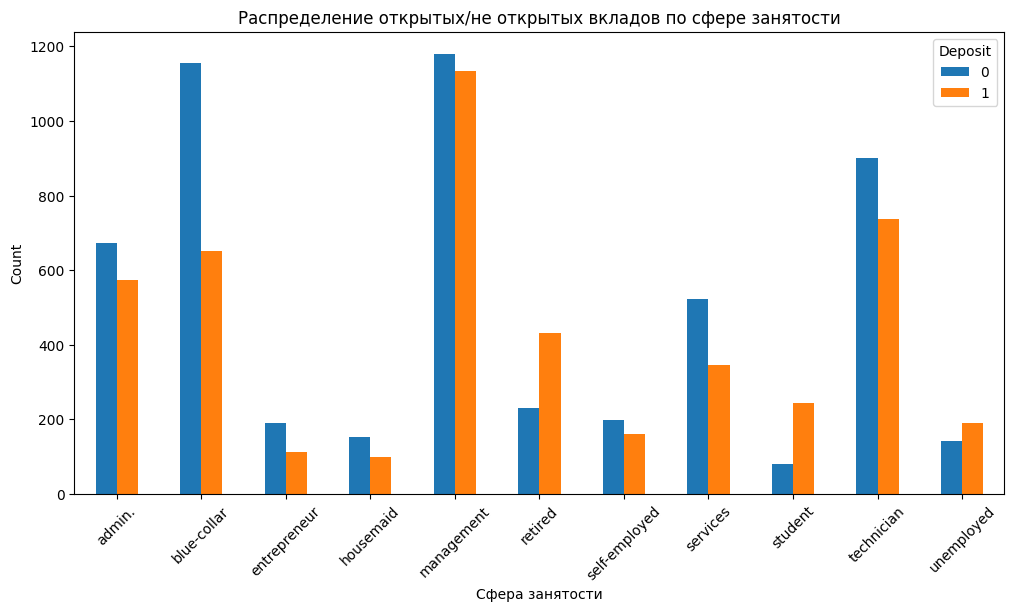

In [24]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
job_data = df.groupby(['job', 'deposit']).size().unstack().fillna(0)
ax = job_data.plot(kind='bar', stacked=False, figsize=(12, 6) )
plt.xlabel('Сфера занятости')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.title('Распределение открытых/не открытых вкладов по сфере занятости')
plt.legend(title='Deposit', labels=['0', '1'])
plt.show()

>По графику видно что наибольшое количество клиентов банка работают в сфере менеджмента (**'management'**), а чаще открывают, чем не открывают депозит клиенты на пенсии (**'retired'**), студенты (**'student'**) и безработные (**'unemployed'**)

### Задание 11

In [25]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
df.pivot_table(
    values='balance',
    index = ['marital', 'education'],
    columns= 'deposit',
    aggfunc= 'count'
)

deposit                0     1
marital  education            
divorced primary      91    96
         secondary   370   283
         tertiary    163   174
married  primary     641   339
         secondary  1830  1289
         tertiary    832   784
single   primary     100    82
         secondary   866   879
         tertiary    531   755

## Часть 3: преобразование данных

### Задание 1

In [26]:
# преобразуйте уровни образования
le = LabelEncoder()
le.fit(df['education'])
df['education'] = le.transform(df['education'])
df['education'].sum()

11995

In [27]:
le.fit(df['age_group'])
df['age_group'] = le.transform(df['age_group'])

### Задания 2 и 3

In [28]:
# Вычисляем стандартное отклонение преобразованой целевой переменной
round(df['deposit'].std(), 3)

0.499

In [29]:
# преобразуйте бинарные переменные в представление из нулей и единиц
bin_columns = ['default', 'housing', 'loan']

for i in bin_columns:
    df[i] = df[i].apply(lambda x:int(1) if x == 'yes' else int(0))
    
round((df['default'].mean() + df['housing'].mean() + df['loan'].mean()), 3)

0.635

### Задание 4

In [30]:
# создайте дамми-переменные
dummies = pd.get_dummies(df[['job', 'marital', 'contact', 'month', 'poutcome']], drop_first=False)
df= pd.concat([df, dummies], axis=1)
len(df.axes[1])-1 # минус целевая переменная

50

In [31]:
df = df.drop(columns=['age', 'job', 'marital', 'contact', 'month', 'poutcome'])

### Задания 5 и 6

<Axes: >

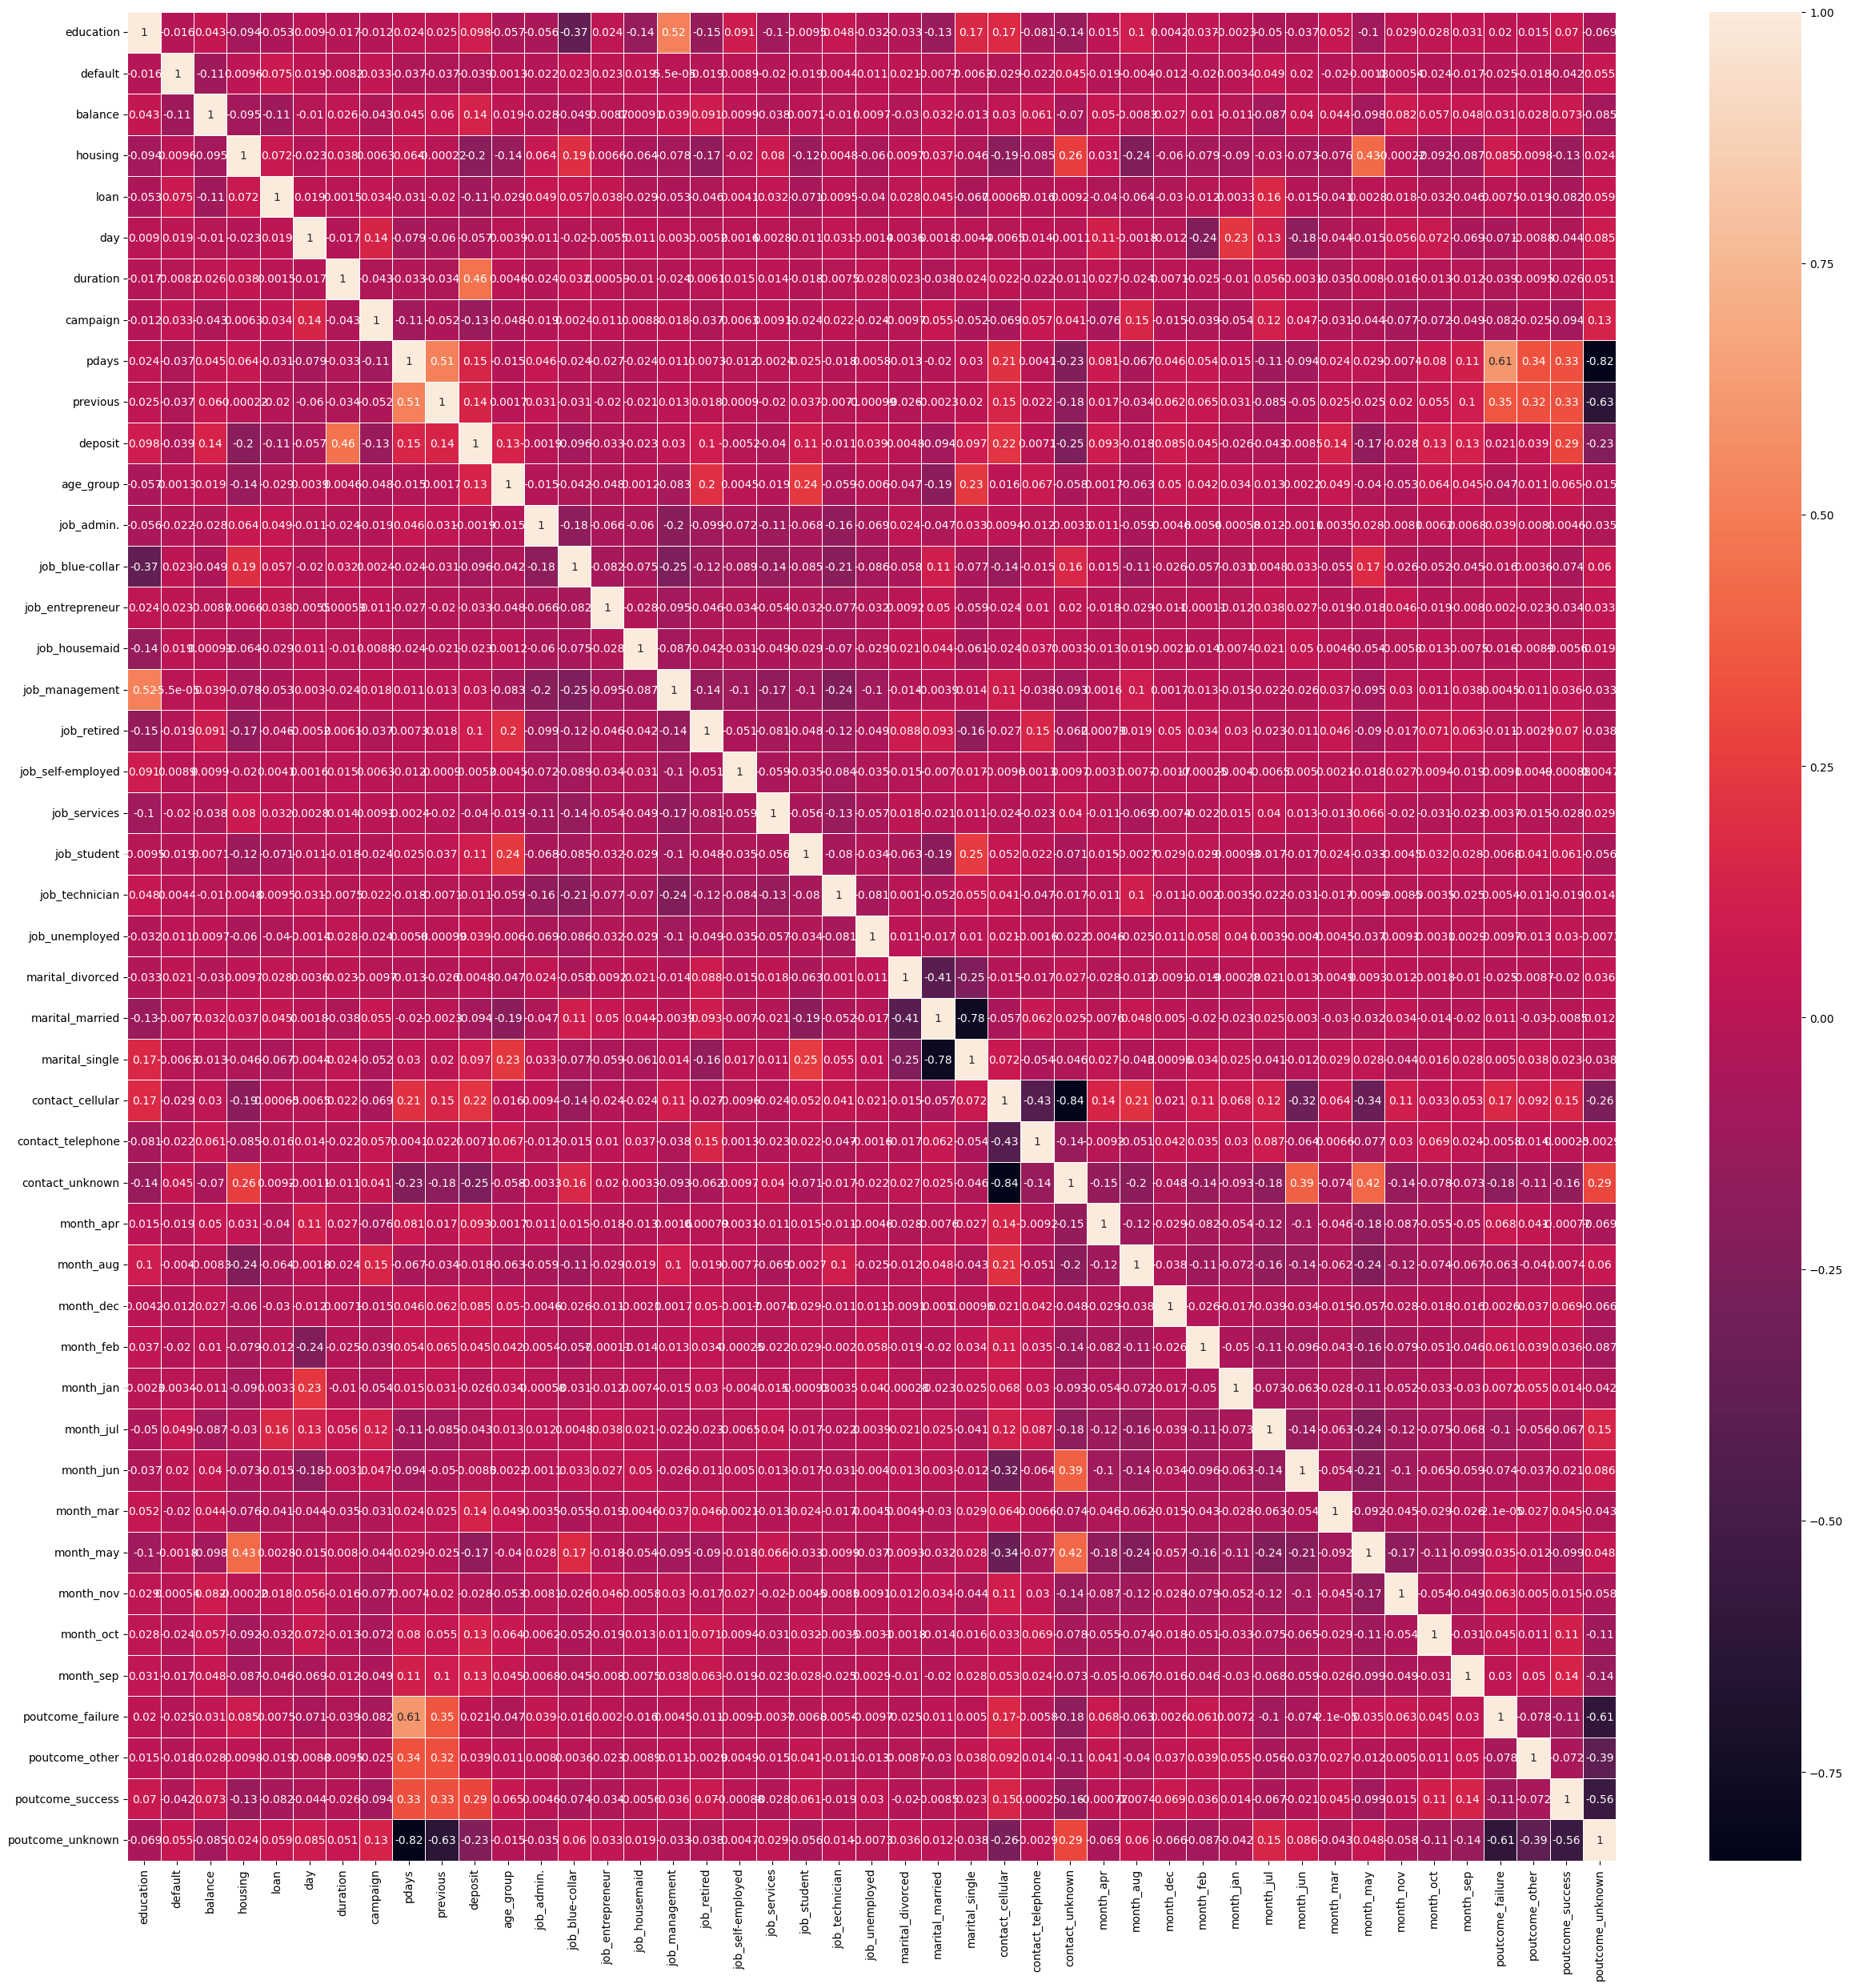

In [32]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
fig, ax = plt.subplots(figsize=(30,30))
sns.heatmap(df.corr(), annot=True, linewidths=.5, ax=ax)

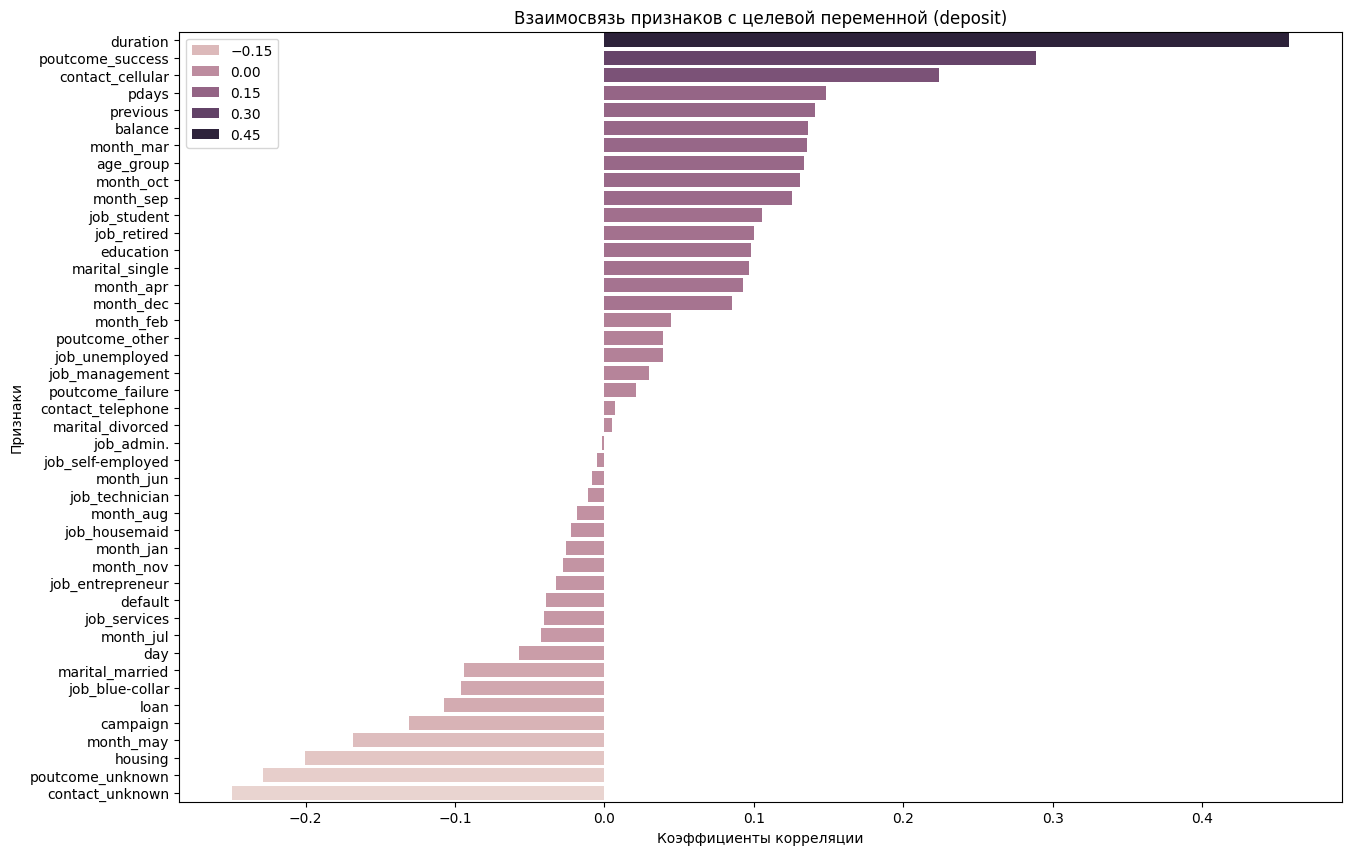

In [33]:
# Вычисление корреляции
corr = df.corr()

# Выбор корреляций с целевой переменной 'deposit'
corr_target = corr["deposit"].drop('deposit')

# Сортировка корреляций
corr_target_sorted = corr_target.sort_values(ascending=False)

# Построение barplot
plt.figure(figsize=(15, 10))
sns.barplot(x=corr_target_sorted.values, y=corr_target_sorted.index, hue = corr_target_sorted.values)
plt.title('Взаимосвязь признаков с целевой переменной (deposit)')
plt.xlabel('Коэффициенты корреляции')
plt.ylabel('Признаки')
plt.show()

### Задания 7 и 8

In [34]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [35]:
# рассчитайте необходимые показатели
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))
print('Среднее значение целевой переменной на тестовой выборке: {}'.format(round(y_test.mean(), 2)))

Train shape: (6770, 44)
Test shape: (3335, 44)
Среднее значение целевой переменной на тестовой выборке: 0.46


### Задание 9

In [36]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector = SelectKBest(score_func = f_classif, k=15)
selector.fit(X_train, y_train)
selector.get_feature_names_out()
selector_col = list(selector.get_feature_names_out())
selector_col



['balance',
 'housing',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'age_group',
 'contact_cellular',
 'contact_unknown',
 'month_mar',
 'month_may',
 'month_oct',
 'month_sep',
 'poutcome_success',
 'poutcome_unknown']

In [37]:
X = df[selector_col]
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

### Задание 10

In [38]:
# нормализуйте данные с помощью minmaxsxaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scal = scaler.fit_transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, columns=X_train.columns)
X_test_scal = scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, columns=X_test.columns)

In [39]:
round(X_test_scal.iloc[:,0].mean(), 2)

0.47

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [40]:
# обучите логистическую регрессию и рассчитайте метрики качества
lr_model = linear_model.LogisticRegression(solver='sag', random_state=42, max_iter=1000)
lr_model.fit(X_train_scal, y_train)
y_test_pred = lr_model.predict(X_test_scal)
print('Test: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Test: 0.81


### Задания 2,3,4

In [41]:
# обучите решающие деревья, настройте максимальную глубину
dt_model = tree.DecisionTreeClassifier(
    criterion='entropy', 
    random_state=42,
    max_depth=6
    )
dt_model.fit(X_train_scal, y_train)
y_train_pred = dt_model.predict(X_train_scal)
print('Train: {:.2f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
y_test_pred = dt_model.predict(X_test_scal)
print('Test: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))

Train: 0.82
Test: 0.81


### Задание 5

In [42]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV

param_grid = {'min_samples_split': [2, 5, 7, 10],
              'max_depth':[3,5,7]
              }

grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state = 42),
    param_grid=param_grid,
    cv = 3,
    n_jobs = -1,
    scoring='f1'
)

%time grid_search.fit(X_train_scal, y_train) 
y_test_pred = grid_search.predict(X_test_scal)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: total: 203 ms
Wall time: 2.26 s
f1_score на тестовом наборе: 0.80
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 7}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [49]:
# обучите на ваших данных случайный лес
rf = ensemble.RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scal, y_train)
y_test_pred = rf.predict(X_test_scal)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3

In [50]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
gbc = ensemble.GradientBoostingClassifier(
    learning_rate= 0.05,
    n_estimators= 300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)

gbc.fit(X_train_scal, y_train)
y_test_pred =gbc.predict(X_test_scal)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 4

In [52]:
# объедините уже известные вам алгоритмы с помощью стекинга 
estimators = [
    ('dt',tree.DecisionTreeClassifier(
        criterion='entropy', 
        random_state=42,
        max_depth=6
    )),
    ('gbc', ensemble.GradientBoostingClassifier(
        learning_rate= 0.05,
        n_estimators= 300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
    ))
]

sr = ensemble.StackingClassifier(
    estimators=estimators,
    final_estimator=linear_model.LogisticRegression(
        solver='sag', 
        random_state=42, 
        max_iter=1000
        )
)

sr.fit(X_train_scal, y_train)
y_test_pred = sr.predict(X_test_scal)
print('precision на тестовом наборе: {:.2f}'.format(metrics.precision_score(y_test, y_test_pred)))

precision на тестовом наборе: 0.80


### Задание 5

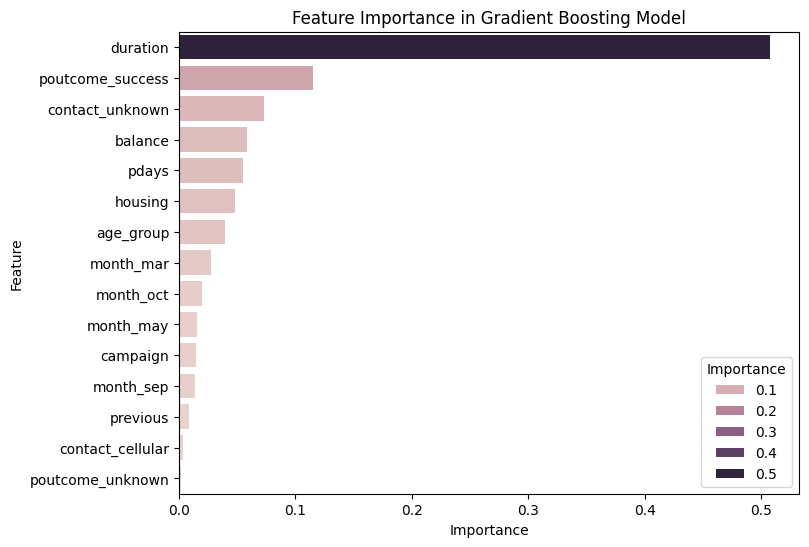

In [56]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
feature_importances = gbc.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue = 'Importance')
plt.title('Feature Importance in Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Задания 6,7,8

In [57]:
import optuna

In [66]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  # создаем модель
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=42)
  # обучаем модель
  model.fit(X_train_scal, y_train)
  score = metrics.accuracy_score(y_test, model.predict(X_test_scal))

  return ('f1_score на тестовом наборе: {:.2f}'.format(score))

%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=10)

[I 2024-07-26 23:48:14,364] A new study created in memory with name: RandomForestClassifier


CPU times: total: 0 ns
Wall time: 0 ns


[W 2024-07-26 23:48:14,948] Trial 0 failed with parameters: {'n_estimators': 174, 'max_depth': 29, 'min_samples_leaf': 5} because of the following error: The value 'f' could not be cast to float.
[W 2024-07-26 23:48:14,949] Trial 0 failed with value 'f1_score на тестовом наборе: 0.83'.
[W 2024-07-26 23:48:15,371] Trial 1 failed with parameters: {'n_estimators': 144, 'max_depth': 29, 'min_samples_leaf': 9} because of the following error: The value 'f' could not be cast to float.
[W 2024-07-26 23:48:15,371] Trial 1 failed with value 'f1_score на тестовом наборе: 0.83'.
[W 2024-07-26 23:48:15,698] Trial 2 failed with parameters: {'n_estimators': 102, 'max_depth': 12, 'min_samples_leaf': 3} because of the following error: The value 'f' could not be cast to float.
[W 2024-07-26 23:48:15,698] Trial 2 failed with value 'f1_score на тестовом наборе: 0.83'.
[W 2024-07-26 23:48:16,406] Trial 3 failed with parameters: {'n_estimators': 197, 'max_depth': 21, 'min_samples_leaf': 3} because of the fo